In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import scanpy as sc
import os
from dotenv import load_dotenv; load_dotenv()
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from itertools import product
import ast

from utils import preprocessing


In [2]:
slidetags = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags.h5ad", backed="r")
nucseq = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad", backed="r"    )

In [3]:
# Same gene format
nucseq.var.index = nucseq.var["gene_symbol"]
slidetags.var.index = slidetags.var["gene_symbol"]

# Gene markers: D1 Matrix

In [5]:
ZONE_COL = "zone"           # <-- adjust
CONDITION_COL = "condition"  # <-- adjust
HEALTHY_LABEL = "Ctrl"       # <-- adjust
DISEASE_LABEL = "XDP"        # <-- adjust

In [6]:
nucseq.obs["ct_for_deg"].value_counts()

ct_for_deg
Oligodendrocyte         123374
Astrocyte                29405
Matrix D2                11504
Matrix D1                11459
Microglia                10209
-Oligo_contamination      8286
OPC                       8155
Neuron_non_MSN            7184
-low_quality_MSN          4581
Patch D1                  3817
eMSN_D1D2                 3693
Patch D2                  2512
Ependymal                 1491
Macrophages               1175
eMSN_StrioMat              870
-TAFA1                     789
Endothelial_BBB            726
Pericytes                  553
eMSN_NUDAP                 551
Lymphocytes                386
Fibroblasts                231
SmoothMuscleCells          129
Name: count, dtype: int64

In [7]:
# Subset to current cell type

mask = (
    (nucseq.obs["ct_for_deg"] == "Matrix D1") &# only QC cells
    (nucseq.obs["zone"].notna())
)
nucseq_d1_matrix = nucseq[mask].to_memory().copy()
print(nucseq_d1_matrix)

mask = (
    slidetags.obs["Group_name"].isin(["STRd D1 Matrix MSN", "STRv D1 MSN"]) &# only D1
    (slidetags.obs["zone"].notna()) # only QC cells
)
slidetag_d1_matrix = slidetags[mask].to_memory().copy()
print(slidetag_d1_matrix)

AnnData object with n_obs × n_vars = 11406 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_ons

In [8]:
# Read reference
ref_d1_matrix_zoning = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/STR_zonation_references_h5ad/STR_D1_Matrix_MSN.h5ad")
# chneg the name of the col that have thezones
ref_d1_matrix_zoning.obs["zone"] = ref_d1_matrix_zoning.obs["Final_Zone_Assignments_No_Smooth"]#"Final_Zone_Assignments_No_Smooth"]
# all healthy
ref_d1_matrix_zoning.obs[CONDITION_COL] = HEALTHY_LABEL

In [9]:
# ── SET raw counts in X ───────────────────────────────────────────────────────
nucseq_d1_matrix.X        = nucseq_d1_matrix.layers["counts"].copy()
slidetag_d1_matrix.X      = slidetag_d1_matrix.layers["counts"].copy()
ref_d1_matrix_zoning.layers["counts"] = ref_d1_matrix_zoning.X.copy() # if not already in layers, set it
# ref already raw

# ── TAG modality ──────────────────────────────────────────────────────────────
nucseq_d1_matrix.obs["modality"]     = "NucSeq"
slidetag_d1_matrix.obs["modality"]   = "Slidetags"
ref_d1_matrix_zoning.obs["modality"] = "Ref"

# ── ALIGN var_names to gene symbols ──────────────────────────────────────────
# nucseq_d1_matrix --< var index alredy gene symbols
# slidetag_d1_matrix --< var index alredy gene symbols
# ref_d1_matrix_zoning --< var index alredy gene symbols

# nucseq_d1_matrix.var
# slidetag_d1_matrix.var
# ref_d1_matrix_zoning.var

# ──HAVE SAME CONDITIONS FORMAT ──────────────────────────────────────────
slidetag_d1_matrix.obs[CONDITION_COL] = slidetag_d1_matrix.obs["state"]
slidetag_d1_matrix.obs[CONDITION_COL] = slidetag_d1_matrix.obs[CONDITION_COL].astype(str).map(
    {"healthy": HEALTHY_LABEL, "diseased": DISEASE_LABEL}
).astype("category")

nucseq_d1_matrix.obs[CONDITION_COL] = nucseq_d1_matrix.obs["condition"]
nucseq_d1_matrix.obs[CONDITION_COL] = nucseq_d1_matrix.obs[CONDITION_COL].astype(str).map(
    {"Control": HEALTHY_LABEL, "XDP": DISEASE_LABEL}
).astype("category")

# ref all healhty alredy done

# ── GENE INTERSECTION across all 3 ───────────────────────────────────────────
common_genes = list(
    set(nucseq_d1_matrix.var_names)
    & set(slidetag_d1_matrix.var_names)
    & set(ref_d1_matrix_zoning.var_names)
)
print(f"Common genes (3-way): {len(common_genes)}")
nucseq_d1_matrix    = nucseq_d1_matrix[:, common_genes].copy()
slidetag_d1_matrix  = slidetag_d1_matrix[:, common_genes].copy()
ref_d1_matrix_zoning = ref_d1_matrix_zoning[:, common_genes].copy()

# ── VERIFY ────────────────────────────────────────────────────────────────────
for name, adata in [("NucSeq", nucseq_d1_matrix), ("Slidetags", slidetag_d1_matrix), ("Ref", ref_d1_matrix_zoning)]:
    print(f"\n{name}: {adata.n_obs} cells | condition: {adata.obs[CONDITION_COL].unique().tolist()} | zones: {sorted(adata.obs[ZONE_COL].dropna().unique().tolist())}")
    print(f"  - condition distribution:\n{adata.obs[CONDITION_COL].value_counts()}")

Common genes (3-way): 29017

NucSeq: 11406 cells | condition: ['XDP', 'Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']
  - condition distribution:
condition
Ctrl    7535
XDP     3871
Name: count, dtype: int64

Slidetags: 8936 cells | condition: ['XDP'] | zones: ['1', '2', '3', '4', '5', '6']
  - condition distribution:
condition
XDP    8936
Name: count, dtype: int64

Ref: 46960 cells | condition: ['Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']
  - condition distribution:
condition
Ctrl    46960
Name: count, dtype: int64


In [10]:
zone_markers_dict = ast.literal_eval(os.getenv("ZONE_MARKERS_D1_MATRIX"))
all_markers = [g for genes in zone_markers_dict.values() for g in genes]
gene_to_zone = {g: z for z, genes in zone_markers_dict.items() for g in genes}

gene_to_zone

{'WLS': '1',
 'KEL': '1',
 'STRIT1': '1',
 'LINC00958': '1',
 'ENSG00000259255': '2',
 'ENSG00000258426': '2',
 'HTR2A': '3',
 'AMIGO2': '3',
 'ENSG00000258181': '3',
 'ENSG00000287925': '4',
 'TIMP2': '4',
 'COL21A1': '4',
 'BAIAP3': '4',
 'SLC5A8': '5',
 'ENSG00000287922': '5',
 'RXFP2': '6',
 'LINC02045': '6'}

In [11]:
# ── NORMALIZE EACH DATASET INDEPENDENTLY ─────────────────────────────────────
datasets = {"NucSeq": nucseq_d1_matrix, "Slidetags": slidetag_d1_matrix, "Ref": ref_d1_matrix_zoning}
for name, adata in datasets.items():
    adata.X = adata.layers["counts"].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)

    adata = adata[:, [g for g in all_markers if g in adata.var_names]].copy()

    sc.pp.log1p(adata)
    adata.layers["log1p_norm"] = adata.X.copy()
    sc.pp.scale(adata)
    adata.layers["scaled"] = adata.X.copy()
    adata.X = adata.layers["counts"].copy()

    datasets[name] = adata  # ← save processed+subsetted adata back
    print(f"{name}: {adata.n_obs} cells | ...")

    print(f"{name}: {adata.n_obs} cells | condition: {adata.obs[CONDITION_COL].unique().tolist()} | zones: {sorted(adata.obs[ZONE_COL].dropna().unique().tolist())}")

NucSeq: 11406 cells | ...
NucSeq: 11406 cells | condition: ['XDP', 'Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Slidetags: 8936 cells | ...
Slidetags: 8936 cells | condition: ['XDP'] | zones: ['1', '2', '3', '4', '5', '6']
Ref: 46960 cells | ...
Ref: 46960 cells | condition: ['Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [12]:
def mean_per_condition(adata, markers, condition_col=CONDITION_COL):
    available = [g for g in markers if g in adata.var_names] # genes available in the adata
    expr = sc.get.obs_df(adata, keys=available, layer="scaled") # make layer a df
    expr[condition_col] = adata.obs[condition_col].astype(str).values # add condition col to the df for each cell
    return expr.groupby(condition_col)[available].mean().T  # genes x condition

df_nucseq    = mean_per_condition(datasets["NucSeq"],    all_markers)
df_slidetags = mean_per_condition(datasets["Slidetags"], all_markers)
df_ref       = mean_per_condition(datasets["Ref"],       all_markers)

rows = []
for gene in all_markers:
    row = {"gene": gene, "marker_zone": gene_to_zone[gene]}
    for cond in [HEALTHY_LABEL, DISEASE_LABEL]:
        for name, df in [("nucseq", df_nucseq), ("slidetags", df_slidetags), ("ref", df_ref)]:
            col = f"{name}_{cond}"
            row[col] = df.loc[gene, cond] if (gene in df.index and cond in df.columns) else np.nan
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("gene")

# drop gene and dataset with nan
summary_df = summary_df.drop(columns=["ref_XDP"])
#summary_df = summary_df.dropna(axis=1, how="any")
#summary_df = summary_df.dropna(axis=1, how="any")

summary_df


,marker_zone,nucseq_Ctrl,slidetags_Ctrl,ref_Ctrl,nucseq_XDP,slidetags_XDP
gene,,,,,,
WLS,1,0.053840,NaN,-9.378500e-17,-0.104802,7.982523e-18
KEL,1,NaN,NaN,NaN,NaN,NaN
STRIT1,1,0.074597,NaN,1.375355e-16,-0.145205,-7.305407e-18
LINC00958,1,0.102766,NaN,8.662387e-18,-0.200037,2.301576e-18
ENSG00000259255,2,0.064351,NaN,5.035604e-17,-0.125260,7.529042e-18
ENSG00000258426,2,NaN,NaN,NaN,NaN,NaN
HTR2A,3,0.035106,NaN,3.719460e-17,-0.068335,-3.211646e-18
AMIGO2,3,-0.014938,NaN,4.027514e-17,0.029077,-2.566832e-17
ENSG00000258181,3,-0.023280,NaN,2.278664e-17,0.045315,3.139585e-17


# Plot

**Preprocessing (independent per dataset):**
1. `normalize_total` (10k) → `log1p` — library-size correction on all genes before subsetting
2. Subset to marker genes only
3. Mean log1p expression computed per **zone × condition** group
4. Scale

**Metric:** mean scaled (z-score) expression per zone × dataset × condition.
Scaled independently per dataset → values represent deviation from that dataset's own mean (0 = average, positive = above average).
This removes technology bias (NucSeq nuclear RNA vs SlideTags total RNA vs Ref) and highlights zone gradients.

**How to read:**
- Red = above dataset mean, Blue = below
- A valid marker should show **red in its marker zone** consistently across datasets
- NaN columns (missing condition/dataset combos) are dropped


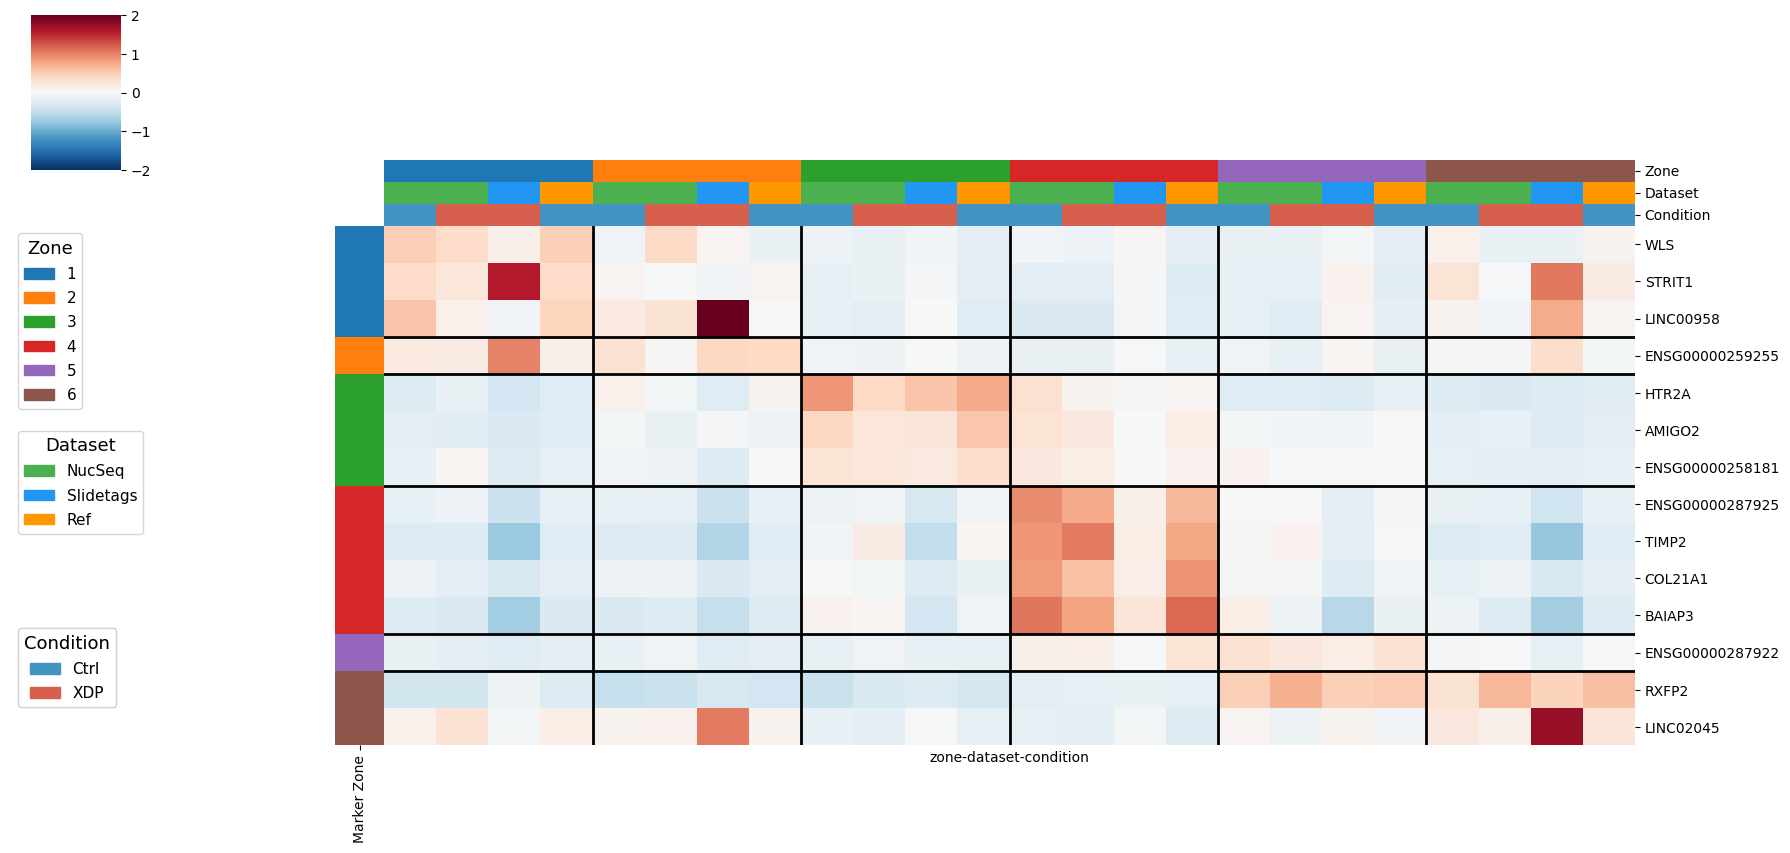

In [21]:
zones         = sorted(set(z for adata in datasets.values() for z in adata.obs[ZONE_COL].astype(str).unique()))
dataset_names = list(datasets.keys())
conditions    = [HEALTHY_LABEL, DISEASE_LABEL]

# ── PALETTES (used by both heatmap cells) ─────────────────────────────────────
zone_pal  = dict(zip(zones, sns.color_palette("tab10", len(zones))))
ds_pal    = {"NucSeq": "#4CAF50", "Slidetags": "#2196F3", "Ref": "#FF9800"}
cond_pal  = {HEALTHY_LABEL: "#4393C3", DISEASE_LABEL: "#D6604D"}

ordered_idx = pd.MultiIndex.from_tuples(
    [(z, ds, c) for z in zones for ds in dataset_names for c in conditions],
    names=["zone", "dataset", "condition"]
)

records = []
for ds_name, adata in datasets.items():
    available = [g for g in all_markers if g in adata.var_names]
    expr = sc.get.obs_df(adata, keys=available, layer="scaled")   # ← scaled
    expr["zone"]      = adata.obs[ZONE_COL].astype(str).values
    expr["condition"] = adata.obs[CONDITION_COL].astype(str).values
    means = expr.groupby(["zone", "condition"])[available].mean()
    means.index = pd.MultiIndex.from_tuples(
        [(z, ds_name, c) for z, c in means.index], names=["zone", "dataset", "condition"]
    )
    records.append(means)

mat_df = pd.concat(records).reindex(ordered_idx).reindex(columns=all_markers).T
mat_df = mat_df.dropna(axis=0, how="all").dropna(axis=1, how="all")
kept_genes     = mat_df.index.tolist()
kept_gene_to_zone = {g: gene_to_zone[g] for g in kept_genes}

col_meta   = mat_df.columns.to_frame(index=False)
col_colors = pd.DataFrame({
    "Zone"     : col_meta["zone"].map(zone_pal).values,
    "Dataset"  : col_meta["dataset"].map(ds_pal).values,
    "Condition": col_meta["condition"].map(cond_pal).values,
}, index=mat_df.columns)
row_colors = pd.Series(kept_gene_to_zone).reindex(kept_genes).map(zone_pal).rename("Marker Zone")

g = sns.clustermap(
    mat_df.fillna(0),
    row_cluster=False, col_cluster=False,
    col_colors=col_colors, row_colors=row_colors,
    cmap="RdBu_r", center=0, vmin=-2, vmax=2,   # ← symmetric around 0
    figsize=(18, len(kept_genes) * 0.4 + 3),
    xticklabels=False, yticklabels=True,
)

ax    = g.ax_heatmap
x_pos = 0
for zone, grp in col_meta.groupby("zone", sort=True):
    n = len(grp)
    if x_pos > 0:
        ax.axvline(x_pos, color="black", lw=2)
    x_pos += n

for i, gene in enumerate(kept_genes[1:], 1):
    if kept_gene_to_zone[gene] != kept_gene_to_zone[kept_genes[i - 1]]:
        ax.axhline(i, color="black", lw=2)

leg_ax = g.ax_row_dendrogram
leg_ax.clear(); leg_ax.axis("off")
y = 1.0
for title, pal in [("Zone", zone_pal), ("Dataset", ds_pal), ("Condition", cond_pal)]:
    handles = [mpatches.Patch(color=c, label=k) for k, c in pal.items()]
    leg = leg_ax.legend(handles=handles, title=title, loc="upper left",
                        bbox_to_anchor=(0, y), fontsize=11, title_fontsize=13,
                        frameon=True, labelspacing=0.6)
    leg_ax.add_artist(leg)
    y -= 0.38

plt.show()


## Zone marker expression heatmap — cell counts

**Each cell = number of cells expressing the gene** (log1p > 0) in that zone × dataset × condition group.

**Color:** row-wise min-max per gene (0→1) — highlights which groups have relatively more expressing cells.
**Number:** raw cell count.

Use this plot alongside the expression heatmap to distinguish:
- Low expression because **few cells express the gene** (low count) vs. **low expression level** (high count but low mean)


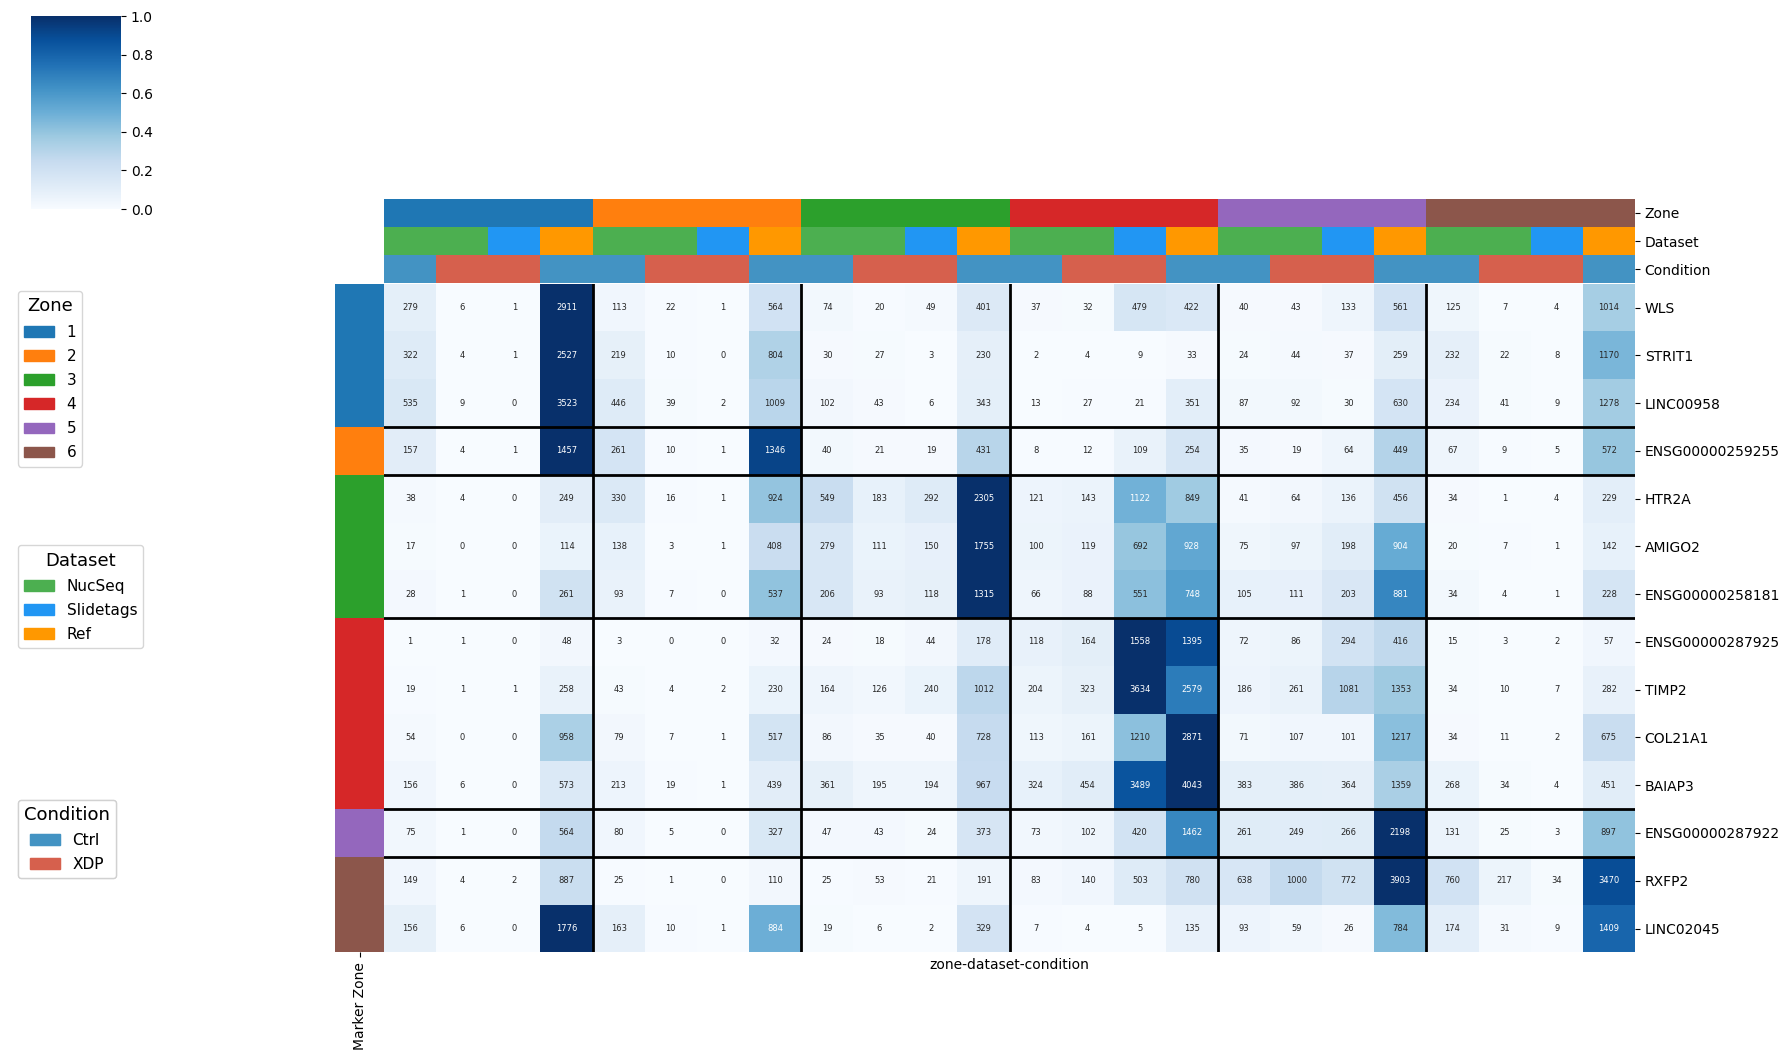

In [22]:
# ── COUNT cells expressing each gene (log1p > 0) per group ────────────────────
count_records = []
for ds_name, adata in datasets.items():
    available = [g for g in all_markers if g in adata.var_names]
    expr = sc.get.obs_df(adata, keys=available, layer="log1p_norm")
    expr["zone"]      = adata.obs[ZONE_COL].astype(str).values
    expr["condition"] = adata.obs[CONDITION_COL].astype(str).values
    counts = expr.groupby(["zone", "condition"])[available].apply(lambda x: (x > 0).sum())
    counts.index = pd.MultiIndex.from_tuples(
        [(z, ds_name, c) for z, c in counts.index], names=["zone", "dataset", "condition"]
    )
    count_records.append(counts)

count_df = pd.concat(count_records).reindex(ordered_idx).reindex(columns=all_markers).T

# drop all-NaN rows/cols (same genes/groups as expression heatmap)
count_df = count_df.loc[kept_genes].dropna(axis=1, how="all")
kept_cols = count_df.columns

# ── ROW-WISE MIN-MAX for color ─────────────────────────────────────────────────
count_norm = count_df.subtract(count_df.min(axis=1), axis=0)
count_norm = count_norm.divide(count_norm.max(axis=1).replace(0, 1), axis=0)

# ── PLOT ──────────────────────────────────────────────────────────────────────
col_meta_c   = kept_cols.to_frame(index=False)
col_colors_c = pd.DataFrame({
    "Zone"     : col_meta_c["zone"].map(zone_pal).values,
    "Dataset"  : col_meta_c["dataset"].map(ds_pal).values,
    "Condition": col_meta_c["condition"].map(cond_pal).values,
}, index=kept_cols)

g2 = sns.clustermap(
    count_norm.fillna(0),
    row_cluster=False, col_cluster=False,
    col_colors=col_colors_c, row_colors=row_colors.reindex(kept_genes),
    cmap="Blues", vmin=0, vmax=1,
    figsize=(18, len(kept_genes) * 0.55 + 3),
    xticklabels=False, yticklabels=True,
    annot=count_df.fillna(0).astype(int),   # ← raw counts as text
    fmt="d", annot_kws={"size": 6},
)

ax2   = g2.ax_heatmap
x_pos = 0
for zone, grp in col_meta_c.groupby("zone", sort=True):
    n = len(grp)
    if x_pos > 0:
        ax2.axvline(x_pos, color="black", lw=2)
    x_pos += n

for i, gene in enumerate(kept_genes[1:], 1):
    if kept_gene_to_zone[gene] != kept_gene_to_zone[kept_genes[i - 1]]:
        ax2.axhline(i, color="black", lw=2)

leg_ax2 = g2.ax_row_dendrogram
leg_ax2.clear(); leg_ax2.axis("off")
y = 1.0
for title, pal in [("Zone", zone_pal), ("Dataset", ds_pal), ("Condition", cond_pal)]:
    handles = [mpatches.Patch(color=c, label=k) for k, c in pal.items()]
    leg = leg_ax2.legend(handles=handles, title=title, loc="upper left",
                         bbox_to_anchor=(0, y), fontsize=11, title_fontsize=13,
                         frameon=True, labelspacing=0.6)
    leg_ax2.add_artist(leg)
    y -= 0.38

plt.show()
